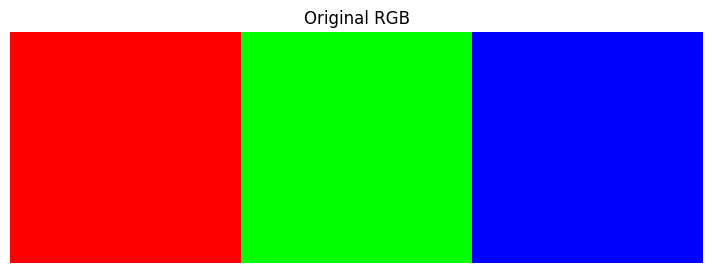

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

rgb = np.zeros((200, 600, 3), dtype=np.uint8)

rgb[:, :200] = [255, 0, 0]      # Red
rgb[:, 200:400] = [0, 255, 0]   # Green
rgb[:, 400:] = [0, 0, 255]      # Blue

plt.figure(figsize=(10, 3))
plt.imshow(rgb)
plt.title("Original RGB")
plt.axis("off")
plt.show()

In [2]:
bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

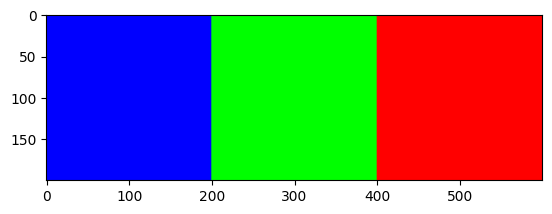

In [3]:
plt.imshow(bgr)

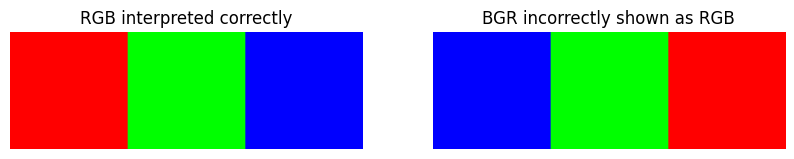

In [4]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("RGB interpreted correctly")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bgr)
plt.title("BGR incorrectly shown as RGB")
plt.axis("off")

plt.show()

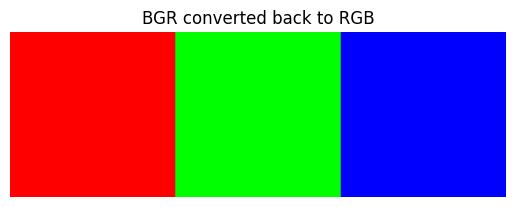

In [5]:
bgr_as_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.imshow(bgr_as_rgb)
plt.title("BGR converted back to RGB")
plt.axis("off")
plt.show()

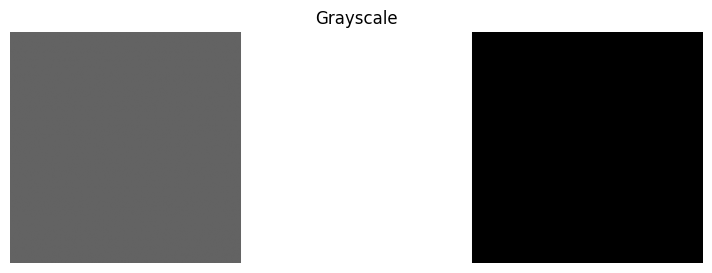

In [6]:
gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(10, 3))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

In [7]:
hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

H, S, V = cv2.split(hsv)

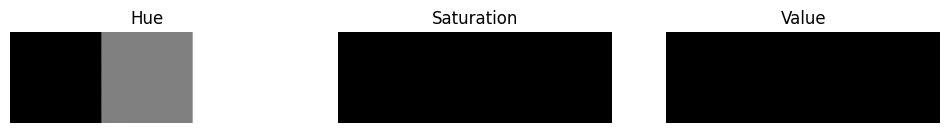

In [8]:
plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.show()

In [9]:
lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)

L, a, b = cv2.split(lab)

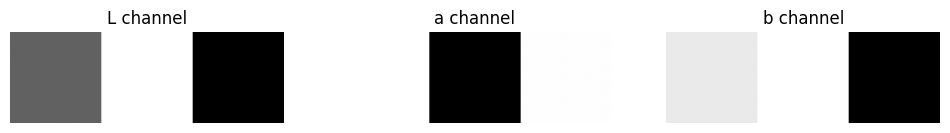

In [10]:
plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
plt.imshow(L, cmap="gray")
plt.title("L channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(a, cmap="gray")
plt.title("a channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(b, cmap="gray")
plt.title("b channel")
plt.axis("off")

plt.show()

In [11]:
dark = np.full((200, 300), 40, dtype=np.uint8)

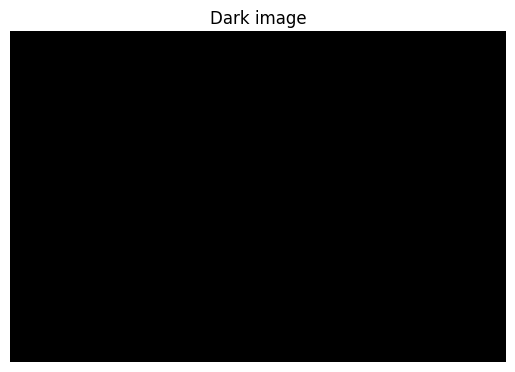

In [12]:
plt.imshow(dark, cmap="gray")
plt.title("Dark image")
plt.axis("off")
plt.show()

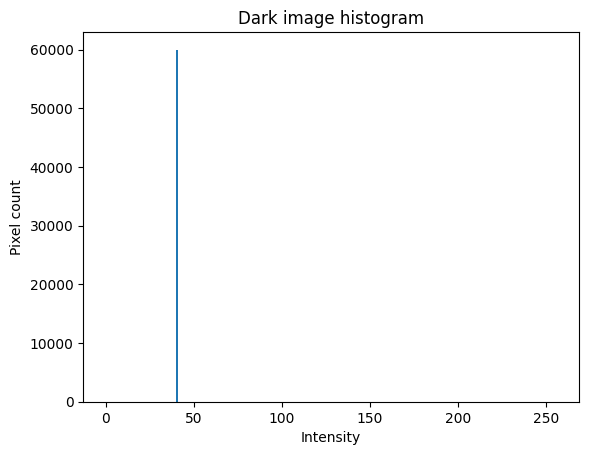

In [13]:
plt.hist(dark.ravel(), bins=256, range=(0, 256))
plt.title("Dark image histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.show()

In [14]:
low_contrast = np.random.randint(
    100,
    131,
    size=(200, 300),
    dtype=np.uint8
)

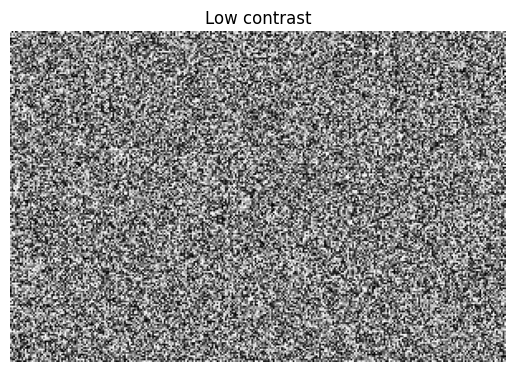

In [15]:
plt.imshow(low_contrast, cmap="gray")
plt.title("Low contrast")
plt.axis("off")
plt.show()

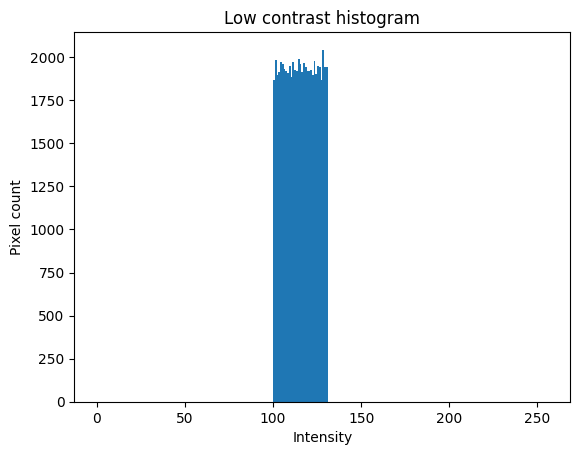

In [16]:
plt.hist(low_contrast.ravel(), bins=256, range=(0, 256))
plt.title("Low contrast histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.show()

In [17]:
high_contrast = np.random.randint(
    0,
    256,
    size=(200, 300),
    dtype=np.uint8
)

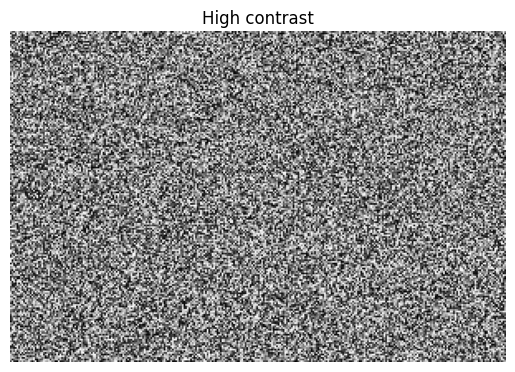

In [18]:
plt.imshow(high_contrast, cmap="gray")
plt.title("High contrast")
plt.axis("off")
plt.show()

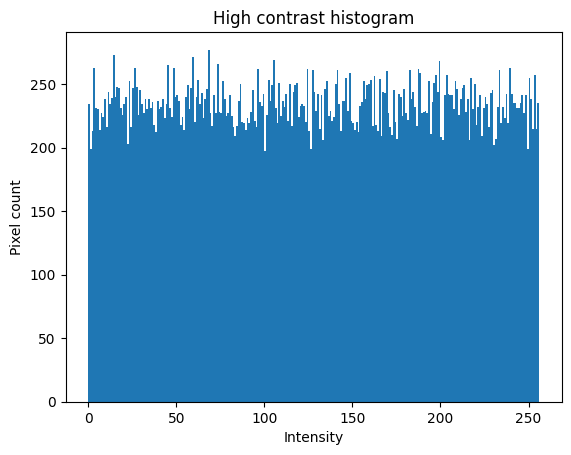

In [19]:
plt.hist(high_contrast.ravel(), bins=256, range=(0, 256))
plt.title("High contrast histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.show()

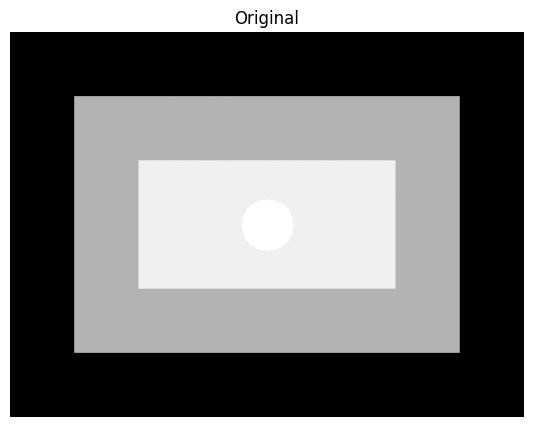

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((300, 400), dtype=np.uint8)

image[50:250, 50:350] = 180
image[100:200, 100:300] = 240

cv2.circle(image, (200, 150), 20, 255, -1)

plt.figure(figsize=(8, 5))
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.show()

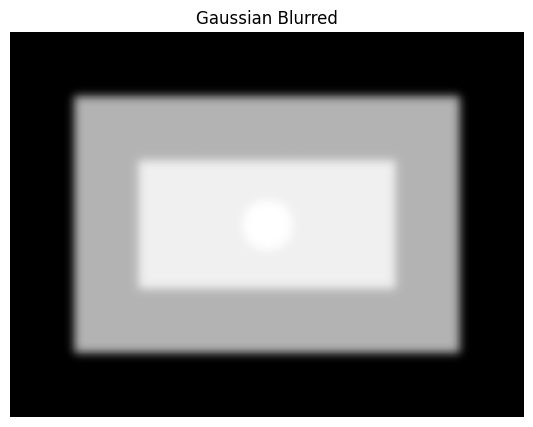

In [21]:
blurred = cv2.GaussianBlur(
    image,
    (21, 21),
    0
)

plt.figure(figsize=(8, 5))
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")
plt.show()

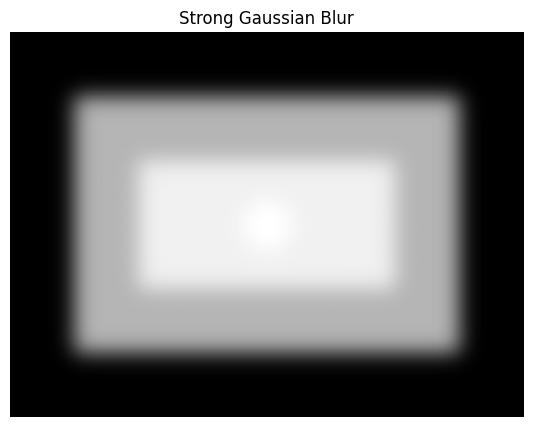

In [22]:
strong_blur = cv2.GaussianBlur(
    image,
    (51, 51),
    0
)

plt.figure(figsize=(8, 5))
plt.imshow(strong_blur, cmap="gray")
plt.title("Strong Gaussian Blur")
plt.axis("off")
plt.show()

In [23]:
rng = np.random.default_rng(42)

noise = rng.normal(
    loc=0,
    scale=25,
    size=image.shape
)

noisy = image.astype(np.float32) + noise

noisy = np.clip(noisy, 0, 255).astype(np.uint8)

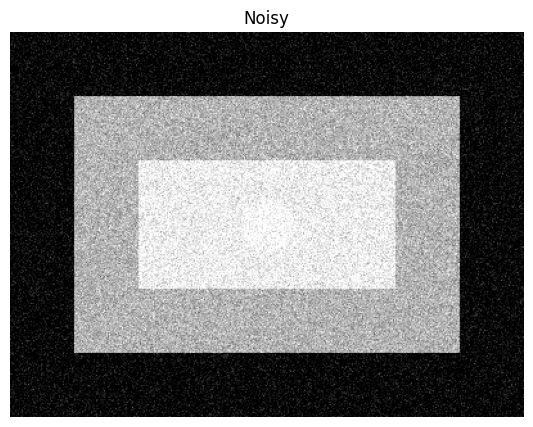

In [24]:
plt.figure(figsize=(8, 5))
plt.imshow(noisy, cmap="gray")
plt.title("Noisy")
plt.axis("off")
plt.show()

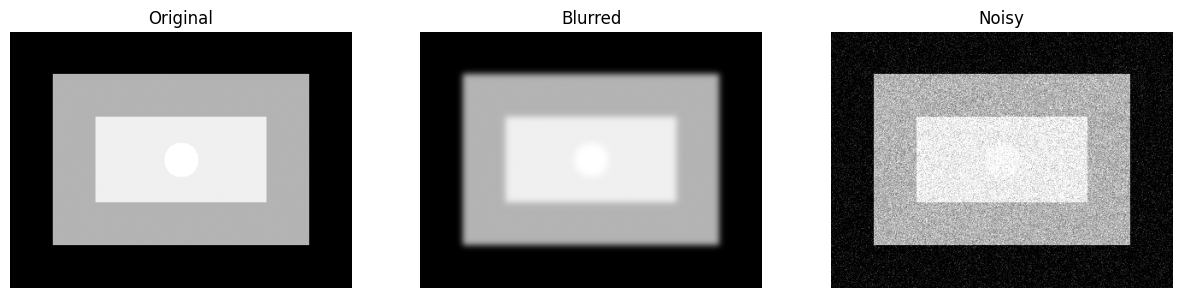

In [25]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Blurred")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.show()

In [26]:
print("Original std:", image.std())
print("Blurred std:", blurred.std())
print("Noisy std:", noisy.std())

Original std: 102.20727560567484
Blurred std: 99.44382331643295
Noisy std: 98.03969120558463


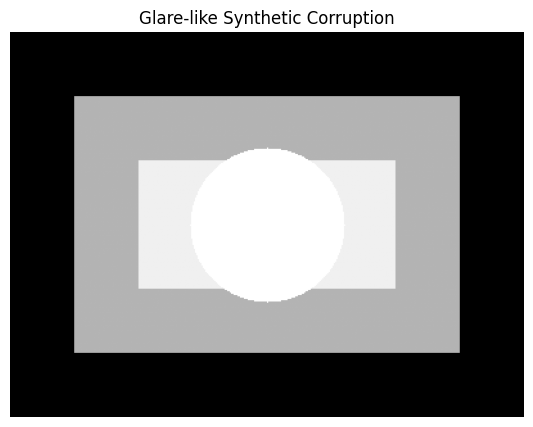

In [27]:
glare = image.copy()

cv2.circle(
    glare,
    (200, 150),
    60,
    255,
    -1
)

plt.figure(figsize=(8, 5))
plt.imshow(glare, cmap="gray")
plt.title("Glare-like Synthetic Corruption")
plt.axis("off")
plt.show()

In [28]:
saturated_pixels = np.sum(glare == 255)

print("Saturated pixels:", saturated_pixels)

Saturated pixels: 11289


In [29]:
encode_params = [
    cv2.IMWRITE_JPEG_QUALITY,
    20
]

success, encoded = cv2.imencode(
    ".jpg",
    image,
    encode_params
)

compressed = cv2.imdecode(
    encoded,
    cv2.IMREAD_GRAYSCALE
)

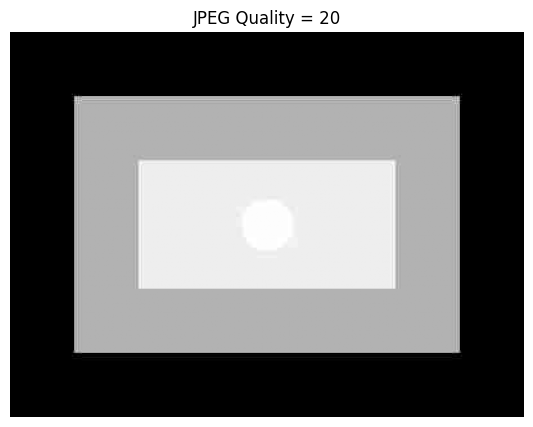

In [30]:
plt.figure(figsize=(8, 5))
plt.imshow(compressed, cmap="gray")
plt.title("JPEG Quality = 20")
plt.axis("off")
plt.show()

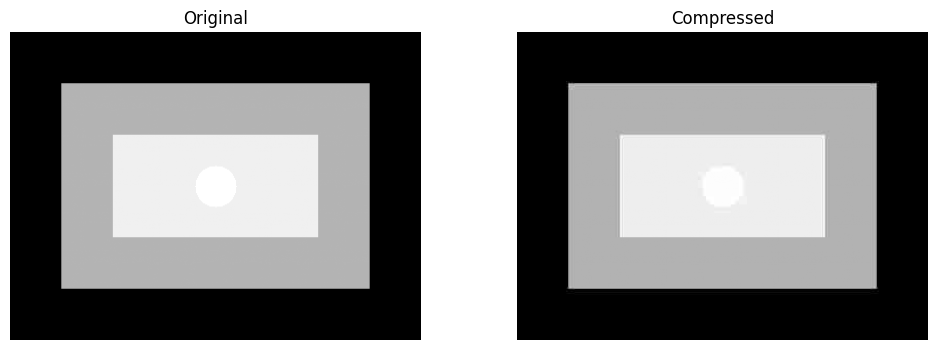

In [31]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(compressed, cmap="gray")
plt.title("Compressed")
plt.axis("off")

plt.show()

In [32]:
import cv2
import numpy as np


def inspect_quality(image):
    laplacian = cv2.Laplacian(
        image,
        cv2.CV_64F
    )

    return {
        "shape": image.shape,
        "dtype": str(image.dtype),
        "min": int(image.min()),
        "max": int(image.max()),
        "mean": float(image.mean()),
        "std": float(image.std()),
        "saturated_ratio": float(np.mean(image >= 250)),
        "laplacian_variance": float(laplacian.var()),
    }

In [33]:
conditions = {
    "Original": image,
    "Blurred": blurred,
    "Noisy": noisy,
    "Glare-like": glare,
    "Compressed": compressed,
}

for name, img in conditions.items():
    result = inspect_quality(img)

    print(f"\n{name}")
    for key, value in result.items():
        print(f"{key}: {value}")


Original
shape: (300, 400)
dtype: uint8
min: 0
max: 255
mean: 100.157125
std: 102.20727560567484
saturated_ratio: 0.010475
laplacian_variance: 579.405

Blurred
shape: (300, 400)
dtype: uint8
min: 0
max: 255
mean: 100.15645833333333
std: 99.44382331643295
saturated_ratio: 0.009041666666666667
laplacian_variance: 1.2884666666666666

Noisy
shape: (300, 400)
dtype: uint8
min: 0
max: 255
mean: 103.96538333333334
std: 98.03969120558463
saturated_ratio: 0.06059166666666667
laplacian_variance: 8044.850233293335

Glare-like
shape: (300, 400)
dtype: uint8
min: 0
max: 255
mean: 101.856625
std: 104.45498943855851
saturated_ratio: 0.094075
laplacian_variance: 596.835

Compressed
shape: (300, 400)
dtype: uint8
min: 0
max: 255
mean: 99.28374166666667
std: 101.21617681477566
saturated_ratio: 0.010375
laplacian_variance: 740.3090333333333


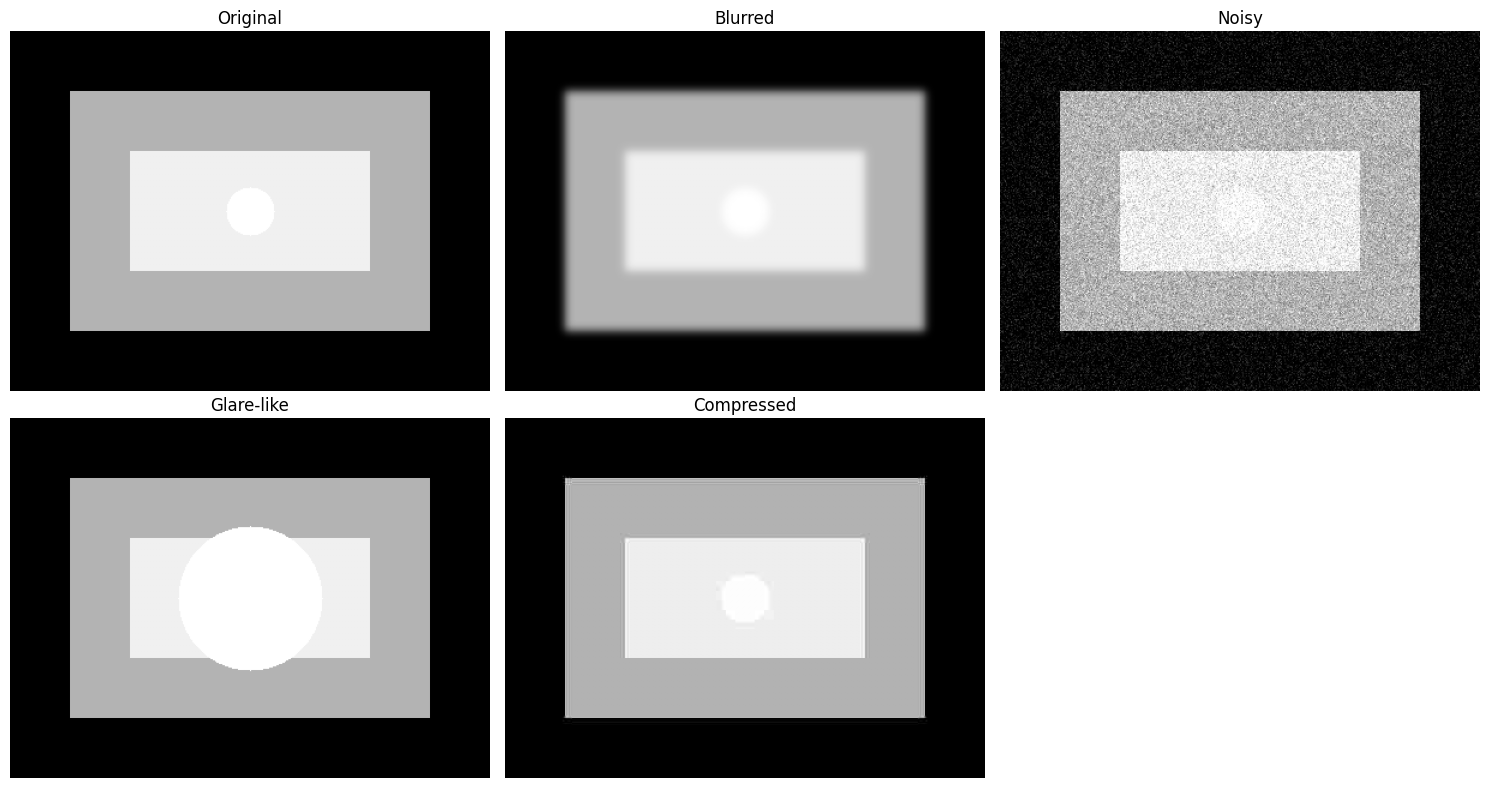

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i, (name, img) in enumerate(conditions.items(), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()